<a href="https://www.kaggle.com/code/kannammaivr/scikit-learn?scriptVersionId=336695360" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

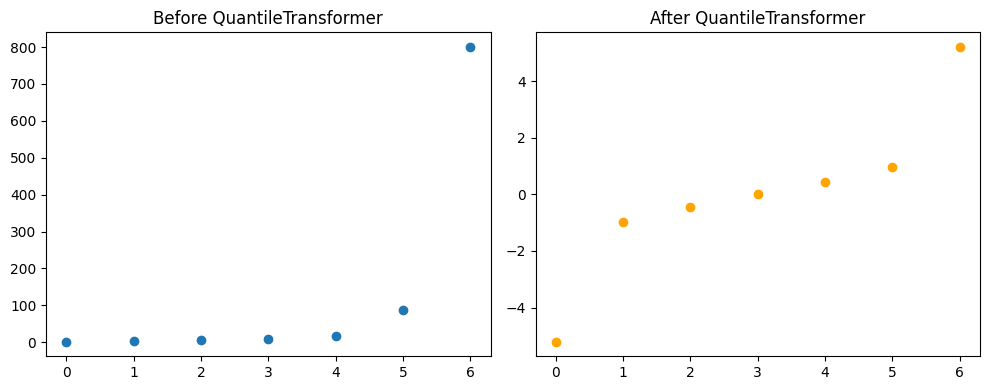

NameError: name 'fit' is not defined

In [8]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import QuantileTransformer
from sklearn.linear_model import LogisticRegression

# Sample data with an outlier (800)
x = np.array([2, 4, 6, 8, 16, 87, 800]).reshape(-1, 1)
y = np.array([0, 0, 0, 1, 1, 1, 1])  # dummy labels just to demo the pipeline

# Build the pipeline
pipeline = Pipeline([
    ('scale', QuantileTransformer(n_quantiles=7, output_distribution='normal', random_state=42)),
    ('model', LogisticRegression())
])

pipeline.fit(x, y)
predictions = pipeline.predict(x)

# To visualize what QuantileTransformer did internally, pull it out of the fitted pipeline
transformed_x = pipeline.named_steps['scale'].transform(x)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(range(len(x)), x)
axes[0].set_title("Before QuantileTransformer")
axes[1].scatter(range(len(transformed_x)), transformed_x, color='orange')
axes[1].set_title("After QuantileTransformer")
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from sklearn.preprocessing import OneHotEncoder

arr = np.array(["High","Low","Medium"]).reshape(-1,1)

enc = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

print(enc.fit_transform(arr))
print(enc.transform(arr))
print(enc.transform(np.array(["new"]).reshape(-1,1)))

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OneHotEncoder

arr =np.array(["High","Low","Medium"]).reshape(-1,1)

enc =OneHotEncoder(sparse_output=False,handle_unknown="ignore")
print(enc.fit_transform(arr))
print(enc.transform(arr))
print(enc.transform(np.array(["new"]).reshape(-1,1))


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder

data = pd.DataFrame({
    'city': ['Delhi', 'Mumbai', 'Pune', 'Delhi', 'Goa', 'Goa', 'Goa', 'Goa', 
              'Chennai', 'Chennai', np.nan, 'Delhi']
})

encoder = OrdinalEncoder(
    handle_unknown='use_encoded_value',
    unknown_value=-1,
    min_frequency=2,
    max_categories=4,
    encoded_missing_value=-99
)

encoded = encoder.fit_transform(data[['city']])
print(encoded)
print(encoder.categories_)

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import sklearn.datasets
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_score, GridSearchCV
from sklearn.model_selection import train_test_split
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
#from sklearn.datasets import fetch_california_housing
from sklearn.datasets import load_diabetes

# Instead of downloading, load as a DataFrame directly
#housing = fetch_california_housing(as_frame=True)
#X = housing.data
#y = housing.target
from sklearn.neighbors import KNeighborsRegressor 
from sklearn.preprocessing import StandardScaler
X,y =load_diabetes (return_X_y =True)
#from sklearn.datasets import preprocessor 
scalar=StandardScaler()
# Always assert this before fitting
assert X.shape[0] == y.shape[0], "Row count mismatch between X and y!"
X_scaled=scalar.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

# --- Step 3: Cross validation (before tuning) ---
mod = PolynomialTransformer()
cv_scores = cross_val_score(mod, X_train, y_train, cv=5, scoring='r2')

print("Cross Validation R2 scores:", cv_scores.round(3))
print("Mean R2:", cv_scores.mean().round(3))
print("Std Dev:", cv_scores.std().round(3))

# --- Step 4: GridSearchCV — find best params ---
param_grid = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}
#mod = KNeighborsRegressor()
#read_model 
mod_grid= GridSearchCV(
    KNeighborsRegressor(),
    param_grid,
    cv=4,
    scoring='r2',
    verbose=1
)

predict_model= mod_grid.fit(X_train,y_train)
best_model = mod_grid.best_estimator_
predictions = best_model.predict(X_test)
print("\nFirst 5 predictions:", predictions[:5].round(1))
print("First 5 actual:     ", y_test[:5])

# --- Step 6: Final test score ---
test_score = best_model.score(X_test, y_test)
pd.DataFrame(test_score)
print(f"\nFinal Test R2 Score: {round(test_score, 3)}")
plt.scatter(predictions,y_test)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README
import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')